In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_auc_score, roc_curve)
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

DATA_PATH = "/content/drive/MyDrive/Group Work_Pipeline_Last.csv"
RESULTS_DIR = "/content/drive/MyDrive/final_results"
PLOTS_DIR = os.path.join(RESULTS_DIR, "plots")
METRICS_DIR = os.path.join(RESULTS_DIR, "metrics")
MODELS_DIR = os.path.join(RESULTS_DIR, "models")
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

In [2]:
# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/Group Work_Pipeline_Last.csv")

print("Dataset shape:", df.shape)
print("First 5 rows:")
print(df.head().to_string(index=False))

Dataset shape: (1953, 10)
First 5 rows:
     age  heart_rate  blood_pressure  sleep_hours  nutrition_quality  activity_index  is_fit  encoded_gender  encoded_smokes      BMI
0.622951    0.429319        0.390738     0.492958              0.237        0.744361       1               0               0 0.438029
0.836066    0.275742        0.358900     0.492958              0.877        0.548872       1               0               0 0.422732
0.459016    0.286213        0.382055     0.492958              0.820        0.258145       0               0               0 0.433645
0.229508    0.265271        0.580318     0.422535              0.618        0.671679       1               1               0 0.326838
0.688525    0.228621        0.373372     0.563380              0.995        0.959900       1               0               1 0.533212


In [3]:
# Check if target column exists
if 'is_fit' not in df.columns:
    raise ValueError("Target column 'is_fit' not found. Please check your CSV file.")

# Separate features (X) and target (y)
X = df.drop('is_fit', axis=1)
y = df['is_fit']

# Split into train (80%) and test (20%) sets, keeping class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain Data")
print(f"Shape: {X_train.shape}")
print(f"Class distribution:\n{y_train.value_counts()}")

print("\nTest Data")
print(f"Shape: {X_test.shape}")
print(f"Class distribution:\n{y_test.value_counts()}")


Train Data
Shape: (1562, 9)
Class distribution:
is_fit
0    938
1    624
Name: count, dtype: int64

Test Data
Shape: (391, 9)
Class distribution:
is_fit
0    235
1    156
Name: count, dtype: int64


In [4]:
# Train a Decision Tree with default settings
baseline_dt = DecisionTreeClassifier(random_state=42)
baseline_dt.fit(X_train, y_train)

# Make predictions
y_pred_baseline = baseline_dt.predict(X_test)
y_prob_baseline = baseline_dt.predict_proba(X_test)[:, 1] if hasattr(baseline_dt, 'predict_proba') else None

# Calculate metrics
train_acc_baseline = accuracy_score(y_train, baseline_dt.predict(X_train))
test_acc_baseline = accuracy_score(y_test, y_pred_baseline)
precision_baseline = precision_score(y_test, y_pred_baseline, zero_division=0)
recall_baseline = recall_score(y_test, y_pred_baseline, zero_division=0)
f1_baseline = f1_score(y_test, y_pred_baseline, zero_division=0)
roc_baseline = roc_auc_score(y_test, y_prob_baseline) if y_prob_baseline is not None else float('nan')
cv_f1_baseline = cross_val_score(baseline_dt, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='f1', n_jobs=-1).mean()

print("\nBaseline Decision Tree Performance (Default Settings):")
print(f" Training Accuracy: {train_acc_baseline:.4f}")
print(f" Test Accuracy:     {test_acc_baseline:.4f}")
print(f" Precision:         {precision_baseline:.4f}")
print(f" Recall:            {recall_baseline:.4f}")
print(f" F1 Score:          {f1_baseline:.4f}")
print(f" ROC-AUC:           {roc_baseline:.4f}")
print(f" CV F1 (5-fold):    {cv_f1_baseline:.4f}")


Baseline Decision Tree Performance (Default Settings):
 Training Accuracy: 1.0000
 Test Accuracy:     0.6752
 Precision:         0.5973
 Recall:            0.5705
 F1 Score:          0.5836
 ROC-AUC:           0.6576
 CV F1 (5-fold):    0.5915


In [5]:
# Define grid of hyperparameters to test
param_grid = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best'],
    'max_depth': [10, 15, 20, 25],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt'],
    'class_weight': [None, 'balanced']
}

# Run GridSearch (5-fold cross-validation, optimized for F1 score)
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("\nBest parameters from GridSearchCV:")
print(grid_search.best_params_)

best_decision_tree_model = grid_search.best_estimator_

Fitting 5 folds for each of 288 candidates, totalling 1440 fits

Best parameters from GridSearchCV:
{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'splitter': 'best'}


In [7]:
# Evaluate the model from GridSearch
y_pred_tuned = best_decision_tree_model.predict(X_test)
y_prob_tuned = best_decision_tree_model.predict_proba(X_test)[:, 1] if hasattr(best_decision_tree_model, 'predict_proba') else None

train_acc_tuned = accuracy_score(y_train, best_decision_tree_model.predict(X_train))
test_acc_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned, zero_division=0)
recall_tuned = recall_score(y_test, y_pred_tuned, zero_division=0)
f1_tuned = f1_score(y_test, y_pred_tuned, zero_division=0)
roc_tuned = roc_auc_score(y_test, y_prob_tuned) if y_prob_tuned is not None else float('nan')
cv_f1_tuned = cross_val_score(best_decision_tree_model, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='f1', n_jobs=-1).mean()

print("\nGridSearch Tuned Model Performance:")
print(f" Training Accuracy: {train_acc_tuned:.4f}")
print(f" Test Accuracy:     {test_acc_tuned:.4f}")
print(f" Precision:         {precision_tuned:.4f}")
print(f" Recall:            {recall_tuned:.4f}")
print(f" F1 Score:          {f1_tuned:.4f}")
print(f" ROC-AUC:           {roc_tuned:.4f}")
print(f" CV F1 (5-fold):    {cv_f1_tuned:.4f}")


GridSearch Tuned Model Performance:
 Training Accuracy: 0.8835
 Test Accuracy:     0.6854
 Precision:         0.6078
 Recall:            0.5962
 F1 Score:          0.6019
 ROC-AUC:           0.7059
 CV F1 (5-fold):    0.6265


In [8]:
# Wider range of hyperparameters for more exploration
param_dist = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [5, 10, 15, 20, 25, 30, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': [None, 'sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

# Run RandomizedSearch (50 random combinations)
random_search = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=50,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train, y_train)

print("\nBest parameters from RandomizedSearchCV:")
print(random_search.best_params_)

further_tuned_model = random_search.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best parameters from RandomizedSearchCV:
{'splitter': 'best', 'min_samples_split': 2, 'min_samples_leaf': 6, 'max_features': 'log2', 'max_depth': 15, 'criterion': 'gini', 'class_weight': 'balanced'}


In [9]:
# Evaluate the model from RandomizedSearch
y_pred_further = further_tuned_model.predict(X_test)
y_prob_further = further_tuned_model.predict_proba(X_test)[:, 1] if hasattr(further_tuned_model, 'predict_proba') else None

train_acc_further = accuracy_score(y_train, further_tuned_model.predict(X_train))
test_acc_further = accuracy_score(y_test, y_pred_further)
precision_further = precision_score(y_test, y_pred_further, zero_division=0)
recall_further = recall_score(y_test, y_pred_further, zero_division=0)
f1_further = f1_score(y_test, y_pred_further, zero_division=0)
roc_further = roc_auc_score(y_test, y_prob_further) if y_prob_further is not None else float('nan')
cv_f1_further = cross_val_score(further_tuned_model, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='f1', n_jobs=-1).mean()

print("\nRandomizedSearch Tuned Model Performance:")
print(f" Training Accuracy: {train_acc_further:.4f}")
print(f" Test Accuracy:     {test_acc_further:.4f}")
print(f" Precision:         {precision_further:.4f}")
print(f" Recall:            {recall_further:.4f}")
print(f" F1 Score:          {f1_further:.4f}")
print(f" ROC-AUC:           {roc_further:.4f}")
print(f" CV F1 (5-fold):    {cv_f1_further:.4f}")


RandomizedSearch Tuned Model Performance:
 Training Accuracy: 0.8444
 Test Accuracy:     0.6803
 Precision:         0.6000
 Recall:            0.5962
 F1 Score:          0.5981
 ROC-AUC:           0.7251
 CV F1 (5-fold):    0.6410


In [10]:
# Function to test and print results for any model
def evaluate_manual_version(model, model_description):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else float('nan')
    cv_f1 = cross_val_score(model, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='f1', n_jobs=-1).mean()

    print(f"\nManual Model: {model_description}")
    print(f" Training Accuracy: {train_acc:.4f}")
    print(f" Test Accuracy:     {test_acc:.4f}")
    print(f" Precision:         {precision:.4f}")
    print(f" Recall:            {recall:.4f}")
    print(f" F1 Score:          {f1:.4f}")
    print(f" ROC-AUC:           {roc:.4f}")
    print(f" CV F1 (5-fold):    {cv_f1:.4f}")

# Model 1: Short tree (to avoid overfitting)
dt_v1 = DecisionTreeClassifier(max_depth=5, criterion='gini', min_samples_split=2, random_state=42)
evaluate_manual_version(dt_v1, "Short tree (max depth = 5)")

# Model 2: Deeper tree using 'entropy' for splits
dt_v2 = DecisionTreeClassifier(max_depth=15, criterion='entropy', min_samples_split=5, random_state=42)
evaluate_manual_version(dt_v2, "Deeper tree using entropy")

# Model 3: Handles imbalanced data
dt_v3 = DecisionTreeClassifier(max_depth=10, criterion='gini', min_samples_leaf=4, class_weight='balanced', random_state=42)
evaluate_manual_version(dt_v3, "Balanced for imbalanced data")

# Model 4: Tree with no depth limit
dt_v4 = DecisionTreeClassifier(max_depth=None, criterion='entropy', max_features='sqrt', random_state=42)
evaluate_manual_version(dt_v4, "Unlimited depth tree")

# Model 5: Custom mix
dt_v5 = DecisionTreeClassifier(max_depth=20, min_samples_split=10, min_samples_leaf=2, random_state=42)
evaluate_manual_version(dt_v5, "Custom combination")


Manual Model: Short tree (max depth = 5)
 Training Accuracy: 0.7907
 Test Accuracy:     0.7161
 Precision:         0.6772
 Recall:            0.5513
 F1 Score:          0.6078
 ROC-AUC:           0.7572
 CV F1 (5-fold):    0.6320

Manual Model: Deeper tree using entropy
 Training Accuracy: 0.9673
 Test Accuracy:     0.6701
 Precision:         0.5944
 Recall:            0.5449
 F1 Score:          0.5686
 ROC-AUC:           0.6749
 CV F1 (5-fold):    0.6183

Manual Model: Balanced for imbalanced data
 Training Accuracy: 0.8886
 Test Accuracy:     0.7289
 Precision:         0.6543
 Recall:            0.6795
 F1 Score:          0.6667
 ROC-AUC:           0.7577
 CV F1 (5-fold):    0.6160

Manual Model: Unlimited depth tree
 Training Accuracy: 1.0000
 Test Accuracy:     0.6931
 Precision:         0.6139
 Recall:            0.6218
 F1 Score:          0.6178
 ROC-AUC:           0.6811
 CV F1 (5-fold):    0.6064

Manual Model: Custom combination
 Training Accuracy: 0.9117
 Test Accuracy:     

In [13]:
# Helper to safely compute ROC-AUC
def safe_roc(y_true, y_prob):
    try:
        return roc_auc_score(y_true, y_prob) if y_prob is not None else float('nan')
    except:
        return float('nan')

# Collect all models
models_info = []

# 1. Baseline
y_pred = baseline_dt.predict(X_test)
y_prob = baseline_dt.predict_proba(X_test)[:, 1] if hasattr(baseline_dt, 'predict_proba') else None
models_info.append({
    'Model': 'Baseline (Default)',
    'Train_Acc': accuracy_score(y_train, baseline_dt.predict(X_train)),
    'Test_Acc': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall': recall_score(y_test, y_pred, zero_division=0),
    'F1': f1_score(y_test, y_pred, zero_division=0),
    'ROC_AUC': safe_roc(y_test, y_prob),
    'CV_F1': cv_f1_baseline
})

# 2. GridSearch
y_pred = best_decision_tree_model.predict(X_test)
y_prob = best_decision_tree_model.predict_proba(X_test)[:, 1] if hasattr(best_decision_tree_model, 'predict_proba') else None
models_info.append({
    'Model': 'GridSearch Tuned',
    'Train_Acc': accuracy_score(y_train, best_decision_tree_model.predict(X_train)),
    'Test_Acc': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall': recall_score(y_test, y_pred, zero_division=0),
    'F1': f1_score(y_test, y_pred, zero_division=0),
    'ROC_AUC': safe_roc(y_test, y_prob),
    'CV_F1': cv_f1_tuned
})

# 3. RandomizedSearch
y_pred = further_tuned_model.predict(X_test)
y_prob = further_tuned_model.predict_proba(X_test)[:, 1] if hasattr(further_tuned_model, 'predict_proba') else None
models_info.append({
    'Model': 'RandomizedSearch Tuned',
    'Train_Acc': accuracy_score(y_train, further_tuned_model.predict(X_train)),
    'Test_Acc': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall': recall_score(y_test, y_pred, zero_division=0),
    'F1': f1_score(y_test, y_pred, zero_division=0),
    'ROC_AUC': safe_roc(y_test, y_prob),
    'CV_F1': cv_f1_further
})

# 4-8. Manual models
manual_models = [
    (dt_v1, "Short tree (max depth = 5)"),
    (dt_v2, "Deeper tree using entropy"),
    (dt_v3, "Balanced for imbalanced data"),
    (dt_v4, "Unlimited depth tree"),
    (dt_v5, "Custom combination")
]
for model, name in manual_models:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    cv_f1_manual = cross_val_score(model, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='f1', n_jobs=-1).mean()
    models_info.append({
        'Model': name,
        'Train_Acc': accuracy_score(y_train, model.predict(X_train)),
        'Test_Acc': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'ROC_AUC': safe_roc(y_test, y_prob),
        'CV_F1': cv_f1_manual
    })

# Show full comparison
all_models_comparison = pd.DataFrame(models_info)
print("COMPARISON OF TREE MODELS")
print(all_models_comparison.to_string(index=False, float_format="%.4f"))

COMPARISON OF TREE MODELS
                       Model  Train_Acc  Test_Acc  Precision  Recall     F1  ROC_AUC  CV_F1
          Baseline (Default)     1.0000    0.6752     0.5973  0.5705 0.5836   0.6576 0.5915
            GridSearch Tuned     0.8835    0.6854     0.6078  0.5962 0.6019   0.7059 0.6265
      RandomizedSearch Tuned     0.8444    0.6803     0.6000  0.5962 0.5981   0.7251 0.6410
  Short tree (max depth = 5)     0.7907    0.7161     0.6772  0.5513 0.6078   0.7572 0.6320
   Deeper tree using entropy     0.9673    0.6701     0.5944  0.5449 0.5686   0.6749 0.6183
Balanced for imbalanced data     0.8886    0.7289     0.6543  0.6795 0.6667   0.7577 0.6160
        Unlimited depth tree     1.0000    0.6931     0.6139  0.6218 0.6178   0.6811 0.6064
          Custom combination     0.9117    0.7136     0.6594  0.5833 0.6190   0.7400 0.6063


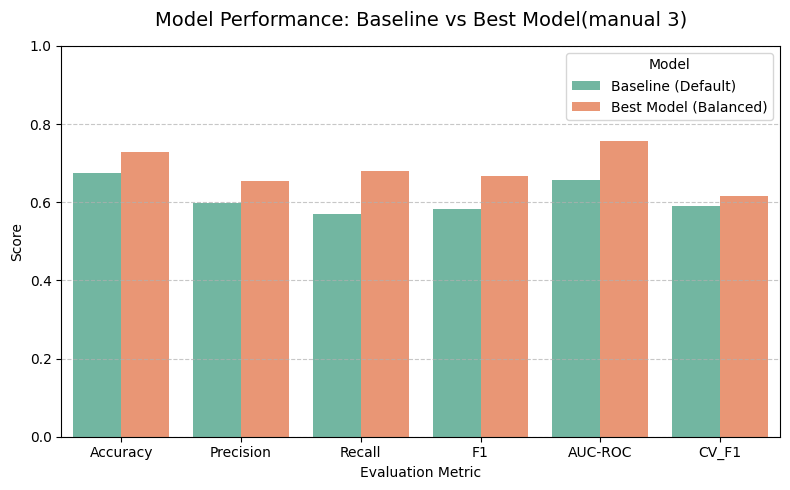

Saved performance plot to: /content/drive/MyDrive/final_results/plots/decision_tree_model_performance.png


In [17]:
# Get predictions from best model
y_pred_best = dt_v3.predict(X_test)
y_prob_best = dt_v3.predict_proba(X_test)[:, 1] if hasattr(dt_v3, 'predict_proba') else None

# Compute metrics for best model
test_acc_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best, zero_division=0)
recall_best = recall_score(y_test, y_pred_best, zero_division=0)
f1_best = f1_score(y_test, y_pred_best, zero_division=0)
roc_best = roc_auc_score(y_test, y_prob_best) if y_prob_best is not None else float('nan')
cv_f1_best = cross_val_score(dt_v3, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='f1', n_jobs=-1).mean()

# Create comparison for plot
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC', 'CV_F1'],
    'Baseline (Default)': [
        test_acc_baseline,
        precision_baseline,
        recall_baseline,
        f1_baseline,
        roc_baseline,
        cv_f1_baseline
    ],
    'Best Model (Balanced)': [
        test_acc_best,
        precision_best,
        recall_best,
        f1_best,
        roc_best,
        cv_f1_best
    ]
})

# Melt for plotting
comparison_melted = comparison.melt(id_vars='Metric', var_name='Model', value_name='Score')

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_melted, x='Metric', y='Score', hue='Model', palette='Set2')
plt.title('Model Performance: Baseline vs Best Model(manual 3)', fontsize=14, pad=15)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.xlabel('Evaluation Metric')
plt.legend(title='Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plot_path = os.path.join(PLOTS_DIR, 'decision_tree_model_performance.png')
try:
    plt.savefig(plot_path)
    plt.show()
    print("Saved performance plot to:", plot_path)
except Exception as e:
    print(f"Error saving plot: {e}")

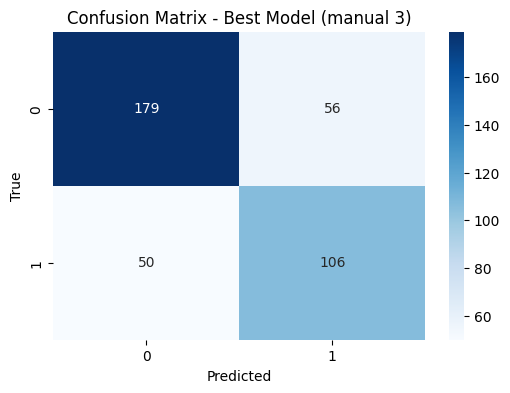

Saved confusion matrix to: /content/drive/MyDrive/final_results/plots/confusion_matrix_dt.png


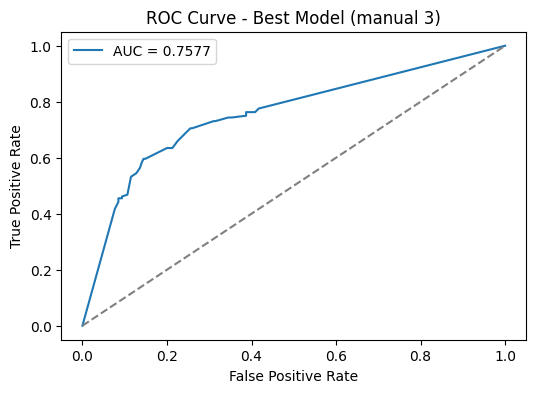

Saved ROC curve to: /content/drive/MyDrive/final_results/plots/roc_curve_dt.png


In [18]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title('Confusion Matrix - Best Model (manual 3)')
plt.xlabel('Predicted')
plt.ylabel('True')
cm_path = os.path.join(PLOTS_DIR, 'confusion_matrix_dt.png')
try:
    plt.savefig(cm_path)
    plt.show()
    print("Saved confusion matrix to:", cm_path)
except Exception as e:
    print(f"Error saving confusion matrix: {e}")

# ROC Curve
if y_prob_best is not None:
    fpr, tpr, _ = roc_curve(y_test, y_prob_best)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob_best):.4f}")
    plt.plot([0,1], [0,1], '--', color='gray')
    plt.title('ROC Curve - Best Model (manual 3)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    roc_path = os.path.join(PLOTS_DIR, 'roc_curve_dt.png')
    try:
        plt.savefig(roc_path)
        plt.show()
        print("Saved ROC curve to:", roc_path)
    except Exception as e:
        print(f"Error saving ROC curve: {e}")

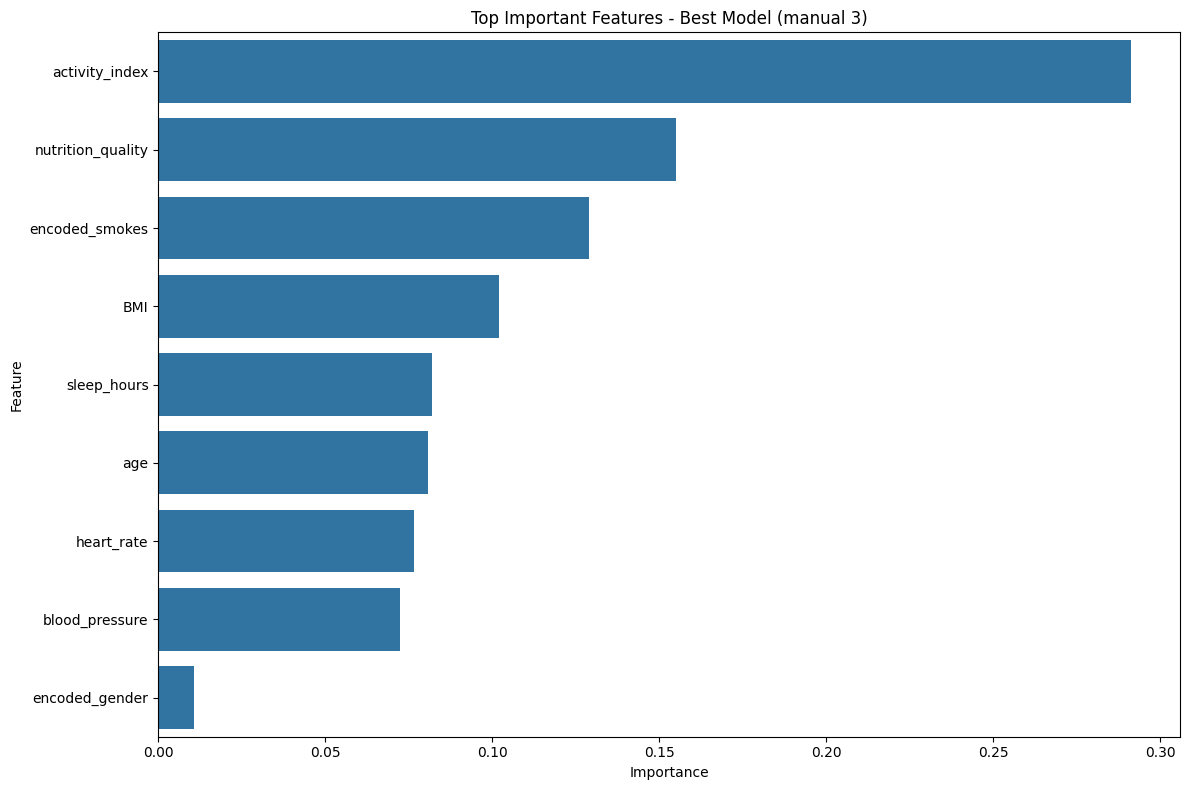

Saved feature importance plot to: /content/drive/MyDrive/final_results/plots/decision_tree_feature_importance.png


In [19]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_v3.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title('Top Important Features - Best Model (manual 3)')
plt.tight_layout()
feat_imp_plot_path = os.path.join(PLOTS_DIR, 'decision_tree_feature_importance.png')
try:
    plt.savefig(feat_imp_plot_path)
    plt.show()
    print("Saved feature importance plot to:", feat_imp_plot_path)
except Exception as e:
    print(f"Error saving feature importance plot: {e}")

In [20]:
# Save metrics
model_metrics = pd.DataFrame({
    'Model': ['Baseline (Default)', 'Best Model (manual 3)'],
    'Train_Accuracy': [train_acc_baseline, accuracy_score(y_train, dt_v3.predict(X_train))],
    'Test_Accuracy': [test_acc_baseline, test_acc_best],
    'Precision': [precision_baseline, precision_best],
    'Recall': [recall_baseline, recall_best],
    'F1_Score': [f1_baseline, f1_best],
    'AUC_ROC': [roc_baseline, roc_best],
    'CV_F1': [cv_f1_baseline, cv_f1_best]
})

metrics_csv_path = os.path.join(METRICS_DIR, 'decision_tree.csv')
try:
    model_metrics.to_csv(metrics_csv_path, index=False)
    print("Saved evaluation metrics to:", metrics_csv_path)
except Exception as e:
    print(f"Error saving metrics CSV: {e}")

# Save feature importances
feat_imp = pd.Series(dt_v3.feature_importances_, index=X.columns).sort_values(ascending=False)
feat_imp_path = os.path.join(METRICS_DIR, 'dt_feature_importances.csv')
try:
    feat_imp.reset_index().rename(columns={'index':'feature', 0:'importance'}).to_csv(feat_imp_path, index=False)
    print("Saved feature importances to:", feat_imp_path)
except Exception as e:
    print(f"Error saving feature importances: {e}")
print("\nTop feature importances:\n", feat_imp.head().to_string())

# Save tree rules
from sklearn.tree import export_text
tree_text = export_text(dt_v3, feature_names=list(X.columns))
rules_path = os.path.join(METRICS_DIR, 'dt_tree_rules.txt')
try:
    with open(rules_path, 'w') as f:
        f.write(tree_text)
    print("Saved tree rules to:", rules_path)
except Exception as e:
    print(f"Error saving tree rules: {e}")
print("\nTop tree rules (truncated):\n", tree_text[:1000])

# Save the best model
model_path = os.path.join(MODELS_DIR, 'decision_tree_model.pkl')
try:
    joblib.dump(dt_v3, model_path)
    print("Saved BEST model (manual 3) to:", model_path)
except Exception as e:
    print(f"Error saving model: {e}")

Saved evaluation metrics to: /content/drive/MyDrive/final_results/metrics/decision_tree.csv
Saved feature importances to: /content/drive/MyDrive/final_results/metrics/dt_feature_importances.csv

Top feature importances:
 activity_index       0.291385
nutrition_quality    0.155108
encoded_smokes       0.128867
BMI                  0.102043
sleep_hours          0.081988
Saved tree rules to: /content/drive/MyDrive/final_results/metrics/dt_tree_rules.txt

Top tree rules (truncated):
 |--- activity_index <= 0.43
|   |--- encoded_smokes <= 0.50
|   |   |--- nutrition_quality <= 0.72
|   |   |   |--- BMI <= 0.46
|   |   |   |   |--- encoded_gender <= 0.50
|   |   |   |   |   |--- blood_pressure <= 0.33
|   |   |   |   |   |   |--- nutrition_quality <= 0.34
|   |   |   |   |   |   |   |--- BMI <= 0.41
|   |   |   |   |   |   |   |   |--- age <= 0.29
|   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |--- age >  0.29
|   |   |   |   |   |   |   |   |   |--- class:

In [24]:
print("- The baseline model overfitted (100% train accuracy but poor test performance).")
print("- best model used 'class_weight=balanced' to handle imbalanced classes.")
print("- This best model achieved:")
print(f"    • Test Accuracy: {test_acc_best:.1%}")
print(f"    • F1 Score:      {f1_best:.4f} (highest among all models)")
print("\nCompleted...!'")

- The baseline model overfitted (100% train accuracy but poor test performance).
- best model used 'class_weight=balanced' to handle imbalanced classes.
- This best model achieved:
    • Test Accuracy: 72.9%
    • F1 Score:      0.6667 (highest among all models)

Completed...!'
